# Lab 02 — N-gram Language Model


In [16]:
import gc
import gzip
import json
import math
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ngram_lm import NGramLanguageModel as NGramLM


LAB_DIR = Path(r"D:\Study\Study_Class\Semester_7\NLP\Lab\lab02")
DATA_PATH = LAB_DIR.parent / "data" / "c4-train.00000-of-01024-30K.json.gz"
RANDOM_SEED = 42
TRAIN_RATIO = 0.8
VALID_RATIO = 0.1

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print("Dataset:", DATA_PATH)


Dataset: D:\Study\Study_Class\Semester_7\NLP\Lab\data\c4-train.00000-of-01024-30K.json.gz


In [17]:
documents = []

with gzip.open(DATA_PATH, "rt", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        try:
            item = json.loads(line)
        except json.JSONDecodeError as error:
            raise ValueError(f"Invalid JSON at line {line_number}") from error

        text = item.get("text", "")
        if text:
            documents.append(text)

print("Number of documents:", len(documents))
print("First document preview:", documents[0][:300])


Number of documents: 30000
First document preview: Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class BBQ Champion, Tony Balay from Lonestar Smoke Rangers. He will be teaching a beginner level class fo


# 13. Experiment 1 — Corpus statistics

Thống kê số documents, sentences, tokens, vocabulary size, số n-gram khác nhau
và số n-gram chỉ xuất hiện một lần.


In [18]:
SENTENCE_SPLIT_PATTERN = re.compile(r"(?<=[.!?])\s+|\n+")
WORD_PATTERN = re.compile(r"[a-z0-9]+(?:['’][a-z0-9]+)*", re.IGNORECASE)


def split_sentences(text):
    text = str(text).strip()
    if not text:
        return []

    return [
        re.sub(r"\s+", " ", sentence).strip()
        for sentence in SENTENCE_SPLIT_PATTERN.split(text)
        if sentence.strip()
    ]


def tokenize(text):
    return WORD_PATTERN.findall(str(text).lower())


def make_ngrams(tokens, n):
    return [
        tuple(tokens[index:index + n])
        for index in range(len(tokens) - n + 1)
    ]


In [19]:
tokenized_documents = []

for document in documents:
    document_sentences = []

    for sentence in split_sentences(document):
        tokens = tokenize(sentence)
        if tokens:
            document_sentences.append(tokens)

    if document_sentences:
        tokenized_documents.append(document_sentences)

number_of_sentences = sum(len(document) for document in tokenized_documents)

print("Number of tokenized documents:", len(tokenized_documents))
print("Number of sentences:", number_of_sentences)
print("Example tokens:", tokenized_documents[0][0][:20])

del documents
gc.collect()


Number of tokenized documents: 30000
Number of sentences: 634941
Example tokens: ['beginners', 'bbq', 'class', 'taking', 'place', 'in', 'missoula']


0

In [20]:
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for document in tokenized_documents:
    for tokens in document:
        unigram_counts.update(tokens)
        bigram_counts.update(make_ngrams(tokens, 2))
        trigram_counts.update(make_ngrams(tokens, 3))

total_tokens = sum(unigram_counts.values())

statistics = {
    "Documents": len(tokenized_documents),
    "Sentences": number_of_sentences,
    "Tokens": total_tokens,
    "Vocabulary size": len(unigram_counts),
    "Unique unigrams": len(unigram_counts),
    "Unique bigrams": len(bigram_counts),
    "Unique trigrams": len(trigram_counts),
    "Singleton unigrams": sum(count == 1 for count in unigram_counts.values()),
    "Singleton bigrams": sum(count == 1 for count in bigram_counts.values()),
    "Singleton trigrams": sum(count == 1 for count in trigram_counts.values()),
}

statistics_df = pd.DataFrame(
    statistics.items(),
    columns=["Statistic", "Value"],
)
display(statistics_df.style.format({"Value": "{:,}"}))


,Statistic,Value
0,Documents,"30,000"
1,Sentences,"634,941"
2,Tokens,"10,972,633"
3,Vocabulary size,"198,797"
4,Unique unigrams,"198,797"
5,Unique bigrams,"2,810,273"
6,Unique trigrams,"6,492,221"
7,Singleton unigrams,"96,418"
8,Singleton bigrams,"2,019,520"
9,Singleton trigrams,"5,616,300"


In [21]:
frequency_rows = []

for name, counts in [
    ("Unigram", unigram_counts),
    ("Bigram", bigram_counts),
    ("Trigram", trigram_counts),
]:
    frequency_rows.append({
        "N-gram": name,
        "Unique": len(counts),
        "Occurrences": sum(counts.values()),
        "Singletons": sum(count == 1 for count in counts.values()),
    })

display(
    pd.DataFrame(frequency_rows).style.format({
        "Unique": "{:,}",
        "Occurrences": "{:,}",
        "Singletons": "{:,}",
    })
)

print("Top 20 unigrams:")
print(unigram_counts.most_common(20))

print("\nTop 20 bigrams:")
print([(" ".join(ngram), count) for ngram, count in bigram_counts.most_common(20)])

print("\nTop 20 trigrams:")
print([(" ".join(ngram), count) for ngram, count in trigram_counts.most_common(20)])


,N-gram,Unique,Occurrences,Singletons
0,Unigram,"198,797","10,972,633","96,418"
1,Bigram,"2,810,273","10,337,692","2,019,520"
2,Trigram,"6,492,221","9,716,968","5,616,300"


Top 20 unigrams:
[('the', 564536), ('and', 323964), ('to', 307713), ('of', 271657), ('a', 244354), ('in', 193891), ('is', 132904), ('for', 125443), ('you', 101700), ('that', 100005), ('with', 91230), ('on', 81719), ('it', 77428), ('i', 76636), ('are', 68784), ('as', 66257), ('this', 65307), ('be', 61731), ('your', 58421), ('or', 55019)]

Top 20 bigrams:
[('of the', 61636), ('in the', 46080), ('to the', 26834), ('on the', 22092), ('for the', 18418), ('and the', 16479), ('is a', 15591), ('to be', 15051), ('with the', 14235), ('at the', 13443), ('it is', 13031), ('from the', 11748), ('you can', 11741), ('in a', 11681), ('if you', 11423), ('with a', 10951), ('will be', 10787), ('is the', 9544), ('as a', 9508), ('for a', 9369)]

Top 20 trigrams:
[('one of the', 4742), ('as well as', 4295), ('a lot of', 2636), ('if you are', 2261), ('be able to', 2094), ('in order to', 1940), ('part of the', 1790), ('some of the', 1770), ('you need to', 1698), ('if you have', 1570), ('you want to', 1565), ('

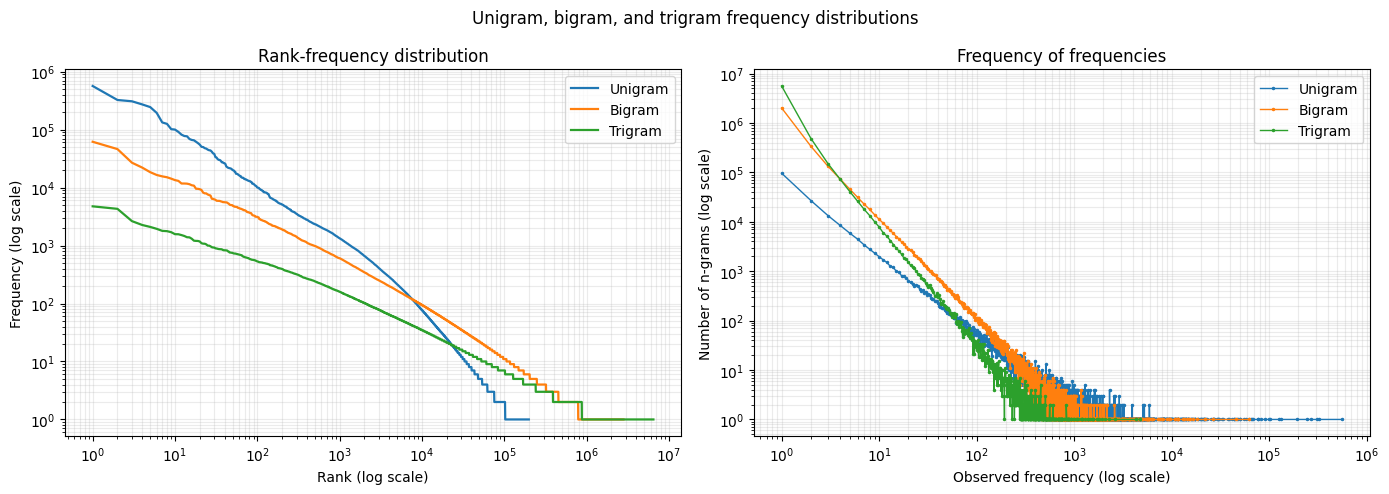

In [22]:
def sampled_rank_frequency(counts, max_points=4000):
    """Return a log-spaced sample of the full rank-frequency curve."""
    frequencies = np.fromiter(
        counts.values(),
        dtype=np.int64,
        count=len(counts),
    )
    frequencies.sort()
    frequencies = frequencies[::-1]

    if len(frequencies) <= max_points:
        indices = np.arange(len(frequencies))
    else:
        indices = np.unique(
            np.geomspace(1, len(frequencies), max_points).astype(np.int64) - 1
        )

    return indices + 1, frequencies[indices]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, counts in [
    ("Unigram", unigram_counts),
    ("Bigram", bigram_counts),
    ("Trigram", trigram_counts),
]:
    ranks, frequencies = sampled_rank_frequency(counts)
    axes[0].loglog(ranks, frequencies, label=name, linewidth=1.6)

    frequency_of_frequency = Counter(counts.values())
    observed_frequencies = np.array(sorted(frequency_of_frequency))
    number_of_ngrams = np.array([
        frequency_of_frequency[frequency]
        for frequency in observed_frequencies
    ])
    axes[1].loglog(
        observed_frequencies,
        number_of_ngrams,
        marker=".",
        markersize=3,
        linewidth=1,
        label=name,
    )

axes[0].set_title("Rank-frequency distribution")
axes[0].set_xlabel("Rank (log scale)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(alpha=0.25, which="both")
axes[0].legend()

axes[1].set_title("Frequency of frequencies")
axes[1].set_xlabel("Observed frequency (log scale)")
axes[1].set_ylabel("Number of n-grams (log scale)")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend()

fig.suptitle("Unigram, bigram, and trigram frequency distributions")
fig.tight_layout()
plt.show()


### Nhận xét — Frequency distribution

- Corpus gồm **30.000 documents**, **634.941 sentences** và **10.972.633
  tokens**, tạo ra vocabulary gồm **198.797 từ**.
- Số loại n-gram tăng rất nhanh theo bậc: **198.797 unigram → 2.810.273
  bigram → 6.492.221 trigram**. Vocabulary không tăng; phần tăng nằm ở số
  chuỗi từ có thứ tự khác nhau.
- Tỷ lệ n-gram chỉ xuất hiện một lần lần lượt xấp xỉ **48,50%**, **71,86%**
  và **86,51%**. Vì vậy sparsity tăng rõ rệt khi chuyển từ unigram sang
  bigram và trigram.
- Đường rank-frequency trên thang log-log có phần đầu dốc và phần đuôi dài:
  một số ít n-gram xuất hiện rất thường xuyên, trong khi phần lớn chỉ xuất
  hiện một hoặc vài lần. Đây là dạng phân phối long-tail thường gặp trong dữ
  liệu ngôn ngữ.
- Các n-gram phổ biến nhất chủ yếu chứa function words, ví dụ `of the`, `in
  the`, `one of the`, `as well as`. Điều này phù hợp với đặc điểm của corpus
  tiếng Anh tổng quát.
- Tổng số occurrence giảm nhẹ khi tăng `n` vì mỗi câu dài `L` chỉ tạo ra
  `L-1` bigram và `L-2` trigram; n-gram không được ghép qua ranh giới câu.


# Prepare train, validation, and test sets

Chia theo **document** để các câu của cùng một document không bị rơi vào nhiều
tập khác nhau. Tỉ lệ sử dụng là 80% / 10% / 10%.


In [23]:
rng = random.Random(RANDOM_SEED)
shuffled_documents = tokenized_documents.copy()
rng.shuffle(shuffled_documents)

number_of_documents = len(shuffled_documents)
train_end = int(TRAIN_RATIO * number_of_documents)
valid_end = int((TRAIN_RATIO + VALID_RATIO) * number_of_documents)


def flatten_documents(document_list):
    return [
        sentence
        for document in document_list
        for sentence in document
    ]


train_corpus = flatten_documents(shuffled_documents[:train_end])
valid_corpus = flatten_documents(shuffled_documents[train_end:valid_end])
test_corpus = flatten_documents(shuffled_documents[valid_end:])

split_summary = pd.DataFrame([
    {"Split": "Train", "Sentences": len(train_corpus), "Tokens": sum(map(len, train_corpus))},
    {"Split": "Validation", "Sentences": len(valid_corpus), "Tokens": sum(map(len, valid_corpus))},
    {"Split": "Test", "Sentences": len(test_corpus), "Tokens": sum(map(len, test_corpus))},
])
display(split_summary.style.format({"Sentences": "{:,}", "Tokens": "{:,}"}))


del tokenized_documents, shuffled_documents
del unigram_counts, bigram_counts, trigram_counts
gc.collect()


,Split,Sentences,Tokens
0,Train,"510,705","8,854,905"
1,Validation,"62,071","1,061,098"
2,Test,"62,165","1,056,630"


5349

# 16. Experiment 2 — MLE vs smoothing

So sánh Bigram/Trigram MLE với Laplace trên train, validation và test. Một
trigram model chứa sẵn các bộ đếm unigram, bigram và trigram, nên chỉ cần fit
**một lần** rồi chọn `order` và `smoothing` khi tính perplexity.


In [24]:
fit_start = time.perf_counter()

language_model = NGramLM(
    n=3,
    smoothing="laplace",
    min_count=1,
)
language_model.fit(train_corpus)

print(f"Model fitted in {time.perf_counter() - fit_start:.2f} seconds")
print("Training tokens:", f"{language_model.total_tokens:,}")
print("Vocabulary size (including <unk>):", f"{len(language_model.vocabulary):,}")


Model fitted in 42.05 seconds
Training tokens: 8,854,905
Vocabulary size (including <unk>): 174,429


In [25]:
corpora = {
    "Train PPL": train_corpus,
    "Valid PPL": valid_corpus,
    "Test PPL": test_corpus,
}
perplexity_cache = {}


def evaluate_perplexity(order, smoothing):
    row = {}

    for split_name, corpus in corpora.items():
        cache_key = (order, smoothing, split_name)

        if cache_key not in perplexity_cache:
            start = time.perf_counter()
            perplexity_cache[cache_key] = language_model.perplexity(
                corpus,
                order=order,
                smoothing=smoothing,
            )
            elapsed = time.perf_counter() - start
            print(
                f"Finished {order}-gram {smoothing} on {split_name}: "
                f"{elapsed:.2f} seconds"
            )

        row[split_name] = perplexity_cache[cache_key]

    return row


experiment_2_settings = [
    ("Bigram MLE", 2, "mle"),
    ("Bigram Laplace", 2, "laplace"),
    ("Trigram MLE", 3, "mle"),
    ("Trigram Laplace", 3, "laplace"),
]

experiment_2_rows = []

for model_name, order, smoothing in experiment_2_settings:
    experiment_2_rows.append({
        "Model": model_name,
        **evaluate_perplexity(order, smoothing),
    })

experiment_2_df = pd.DataFrame(experiment_2_rows)
display(experiment_2_df)

experiment_2_df.to_csv(
    LAB_DIR / "experiment_2_results.csv",
    index=False,
)


Finished 2-gram mle on Train PPL: 17.02 seconds
Finished 2-gram mle on Valid PPL: 0.00 seconds
Finished 2-gram mle on Test PPL: 0.00 seconds
Finished 2-gram laplace on Train PPL: 15.54 seconds
Finished 2-gram laplace on Valid PPL: 1.75 seconds
Finished 2-gram laplace on Test PPL: 1.68 seconds
Finished 3-gram mle on Train PPL: 17.78 seconds
Finished 3-gram mle on Valid PPL: 0.00 seconds
Finished 3-gram mle on Test PPL: 0.00 seconds
Finished 3-gram laplace on Train PPL: 16.17 seconds
Finished 3-gram laplace on Valid PPL: 2.13 seconds
Finished 3-gram laplace on Test PPL: 2.07 seconds


,Model,Train PPL,Valid PPL,Test PPL
0,Bigram MLE,192.851959,inf,inf
1,Bigram Laplace,6329.305560,8.330500e+03,8.337020e+03
2,Trigram MLE,16.463478,inf,inf
3,Trigram Laplace,31476.137829,5.228808e+04,5.238912e+04


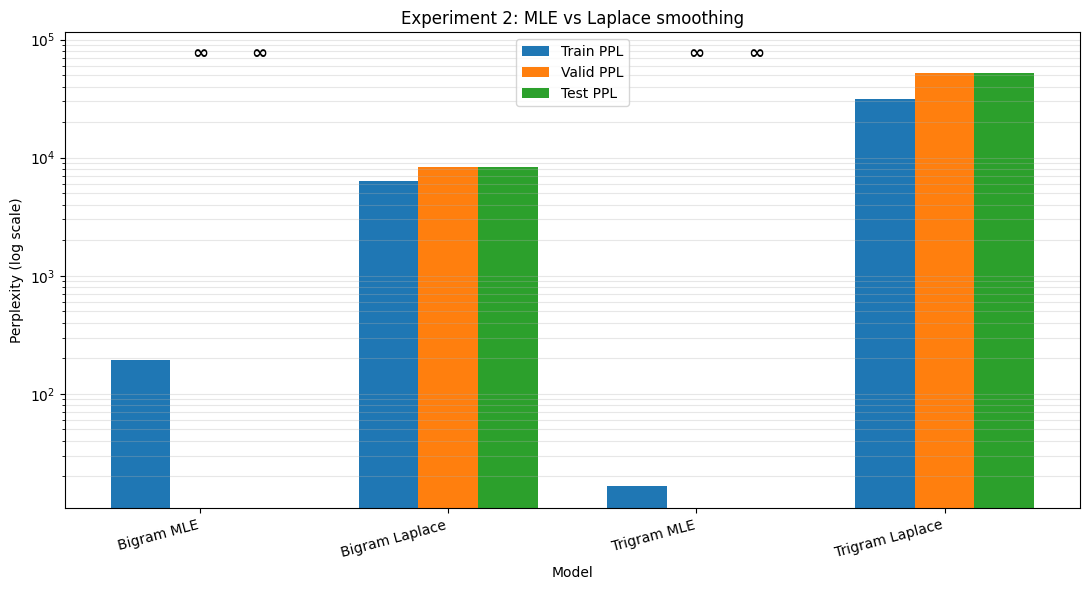

In [26]:
def plot_perplexity_results(result_df, title):
    split_columns = ["Train PPL", "Valid PPL", "Test PPL"]
    x_positions = np.arange(len(result_df))
    width = 0.24

    all_values = result_df[split_columns].to_numpy(dtype=float)
    finite_values = all_values[np.isfinite(all_values) & (all_values > 0)]

    if finite_values.size == 0:
        raise ValueError("No finite positive perplexity value to plot")

    minimum_value = finite_values.min()
    maximum_value = finite_values.max()

    fig, ax = plt.subplots(figsize=(11, 6))

    for split_index, split_name in enumerate(split_columns):
        values = result_df[split_name].to_numpy(dtype=float)
        bar_positions = x_positions + (split_index - 1) * width
        plotted_values = np.where(np.isfinite(values), values, np.nan)

        bars = ax.bar(
            bar_positions,
            plotted_values,
            width,
            label=split_name,
        )

        for position, value in zip(bar_positions, values):
            if not np.isfinite(value):
                ax.text(
                    position,
                    maximum_value * 1.45,
                    "∞",
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold",
                )

    ax.set_yscale("log")
    ax.set_ylim(minimum_value * 0.65, maximum_value * 2.2)
    ax.set_xticks(x_positions, result_df["Model"], rotation=15, ha="right")
    ax.set_xlabel("Model")
    ax.set_ylabel("Perplexity (log scale)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_perplexity_results(
    experiment_2_df,
    "Experiment 2: MLE vs Laplace smoothing",
)


### Nhận xét — Experiment 2: MLE vs smoothing

- Trên training set, **Trigram MLE đạt PPL 16,46**, thấp hơn nhiều so với
  **Bigram MLE 192,85**. Trigram sử dụng context cụ thể hơn và có khả năng
  khớp hoặc ghi nhớ training data tốt hơn.
- Trên validation và test, cả Bigram MLE lẫn Trigram MLE đều cho **PPL =
  `inf`**. Chỉ cần một n-gram chưa xuất hiện trong training có xác suất MLE
  bằng 0 thì log probability của corpus trở thành `-inf` và perplexity trở
  thành `inf`. Thời gian hiển thị gần 0 giây là do hàm có thể kết thúc ngay
  khi gặp sự kiện xác suất 0 đầu tiên.
- Laplace loại bỏ zero probability nên cho kết quả hữu hạn. Bigram Laplace
  đạt khoảng **6.329 / 8.330 / 8.337** trên train/validation/test; Trigram
  Laplace đạt khoảng **31.476 / 52.288 / 52.389**.
- Trigram Laplace có PPL cao hơn Bigram Laplace vì trigram thưa hơn, trong khi
  add-one phải phân phối thêm xác suất cho toàn bộ vocabulary gồm khoảng
  **174.429 từ**. Khi context có ít count, thành phần `+V` trong mẫu số tạo
  mức phạt rất lớn.
- Validation PPL và Test PPL của từng model gần nhau, cho thấy hai tập đánh
  giá có độ khó và phân phối tương đối tương đồng dưới cùng preprocessing và
  cách chia dữ liệu.
- Kết quả không nên được diễn giải đơn giản là “context dài luôn xấu”. MLE cho
  thấy trigram khớp train tốt, còn Laplace cho thấy add-one smoothing không
  phù hợp với vocabulary lớn và phân phối trigram rất sparse.


# 19. Experiment 3 — Perplexity

So sánh Unigram, Bigram và Trigram trên cùng train/validation/test. Phần này
dùng Laplace để cả ba mô hình có kết quả hữu hạn và so sánh được.


In [27]:
experiment_3_rows = []

for model_name, order in [
    ("Unigram", 1),
    ("Bigram", 2),
    ("Trigram", 3),
]:
    experiment_3_rows.append({
        "Model": model_name,
        **evaluate_perplexity(order, "laplace"),
    })

experiment_3_df = pd.DataFrame(experiment_3_rows)
display(experiment_3_df)

experiment_3_df.to_csv(
    LAB_DIR / "experiment_3_results.csv",
    index=False,
)


Finished 1-gram laplace on Train PPL: 8.18 seconds
Finished 1-gram laplace on Valid PPL: 0.93 seconds
Finished 1-gram laplace on Test PPL: 0.89 seconds


,Model,Train PPL,Valid PPL,Test PPL
0,Unigram,2149.186168,2267.198562,2269.985133
1,Bigram,6329.305560,8330.499754,8337.019739
2,Trigram,31476.137829,52288.082942,52389.115357


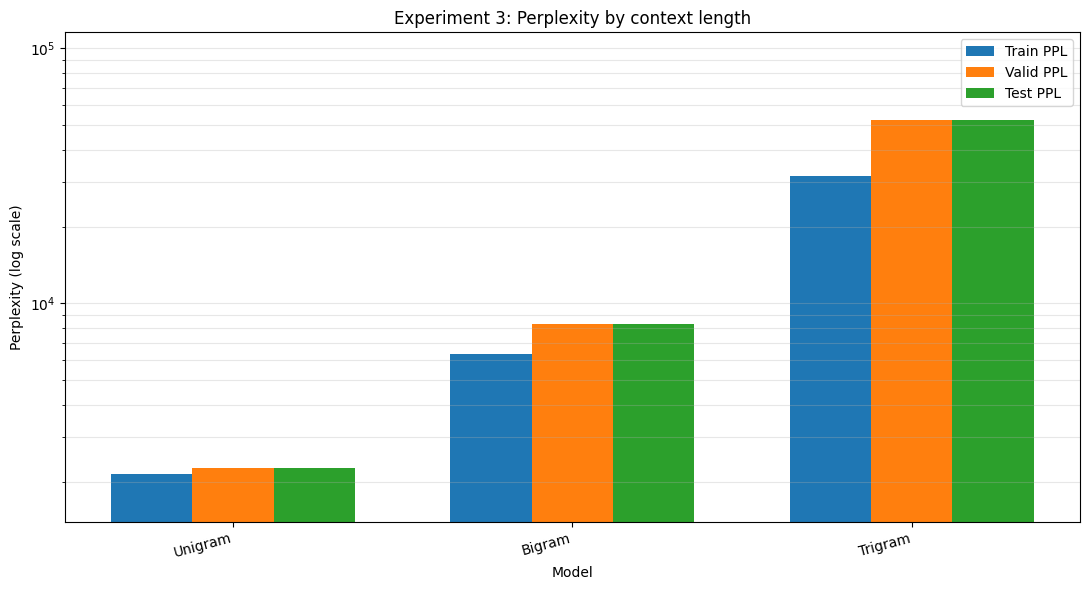

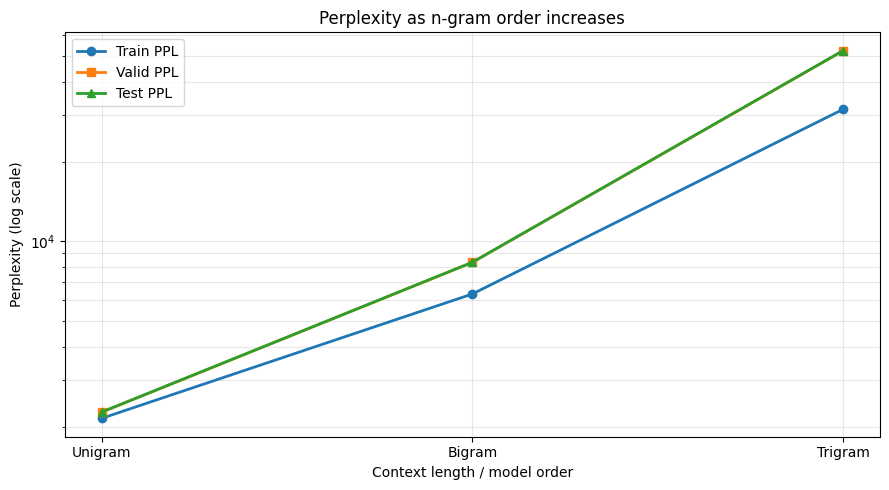

In [28]:
plot_perplexity_results(
    experiment_3_df,
    "Experiment 3: Perplexity by context length",
)

fig, ax = plt.subplots(figsize=(9, 5))
orders = np.arange(1, 4)

for split_name, marker in [
    ("Train PPL", "o"),
    ("Valid PPL", "s"),
    ("Test PPL", "^"),
]:
    ax.plot(
        orders,
        experiment_3_df[split_name],
        marker=marker,
        linewidth=2,
        label=split_name,
    )

ax.set_yscale("log")
ax.set_xticks(orders, ["Unigram", "Bigram", "Trigram"])
ax.set_xlabel("Context length / model order")
ax.set_ylabel("Perplexity (log scale)")
ax.set_title("Perplexity as n-gram order increases")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()


,Model,Unique train n-grams,Singleton train n-grams,Validation events,Validation unseen,Validation unseen rate,Test events,Test unseen,Test unseen rate
0,Unigram,"174,428","83,729","1,061,098","19,986",1.88%,"1,056,630","21,024",1.99%
1,Bigram,"2,383,554","1,720,570","999,027","245,504",24.57%,"994,465","246,238",24.76%
2,Trigram,"5,360,175","4,657,555","938,290","604,989",64.48%,"933,790","600,764",64.34%


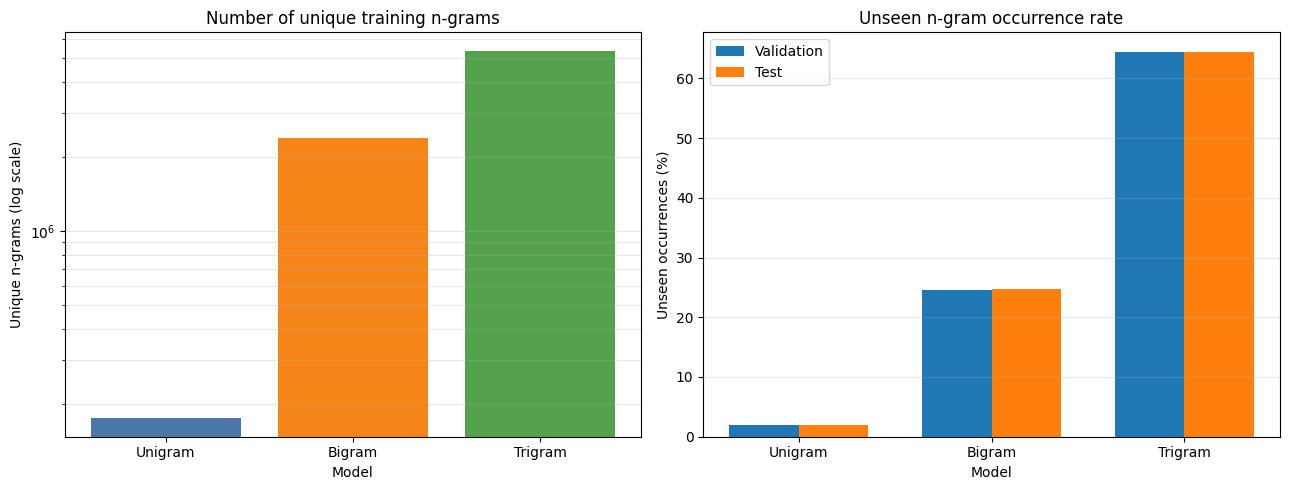

In [29]:
def count_unseen_ngram_occurrences(model, corpus, order):
    training_counts = {
        1: model.unigram_counts,
        2: model.bigram_counts,
        3: model.trigram_counts,
    }[order]

    total_occurrences = 0
    unseen_occurrences = 0

    for sentence in corpus:
        mapped_tokens = [
            token if token in model.vocabulary else model.unk_token
            for token in sentence
        ]

        number_of_events = len(mapped_tokens) - order + 1
        if number_of_events <= 0:
            continue

        total_occurrences += number_of_events

        for index in range(number_of_events):
            ngram = tuple(mapped_tokens[index:index + order])
            if training_counts.get(ngram, 0) == 0:
                unseen_occurrences += 1

    unseen_rate = (
        unseen_occurrences / total_occurrences
        if total_occurrences
        else 0.0
    )
    return total_occurrences, unseen_occurrences, unseen_rate


context_length_rows = []

for order, model_name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    training_counts = {
        1: language_model.unigram_counts,
        2: language_model.bigram_counts,
        3: language_model.trigram_counts,
    }[order]

    valid_total, valid_unseen, valid_rate = count_unseen_ngram_occurrences(
        language_model,
        valid_corpus,
        order,
    )
    test_total, test_unseen, test_rate = count_unseen_ngram_occurrences(
        language_model,
        test_corpus,
        order,
    )

    context_length_rows.append({
        "Model": model_name,
        "Unique train n-grams": len(training_counts),
        "Singleton train n-grams": sum(
            count == 1 for count in training_counts.values()
        ),
        "Validation events": valid_total,
        "Validation unseen": valid_unseen,
        "Validation unseen rate": valid_rate,
        "Test events": test_total,
        "Test unseen": test_unseen,
        "Test unseen rate": test_rate,
    })

context_length_df = pd.DataFrame(context_length_rows)
display(
    context_length_df.style.format({
        "Unique train n-grams": "{:,}",
        "Singleton train n-grams": "{:,}",
        "Validation events": "{:,}",
        "Validation unseen": "{:,}",
        "Validation unseen rate": "{:.2%}",
        "Test events": "{:,}",
        "Test unseen": "{:,}",
        "Test unseen rate": "{:.2%}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    context_length_df["Model"],
    context_length_df["Unique train n-grams"],
    color=["#4c78a8", "#f58518", "#54a24b"],
)
axes[0].set_yscale("log")
axes[0].set_title("Number of unique training n-grams")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Unique n-grams (log scale)")
axes[0].grid(axis="y", alpha=0.3, which="both")

x_positions = np.arange(len(context_length_df))
width = 0.36
axes[1].bar(
    x_positions - width / 2,
    context_length_df["Validation unseen rate"] * 100,
    width,
    label="Validation",
)
axes[1].bar(
    x_positions + width / 2,
    context_length_df["Test unseen rate"] * 100,
    width,
    label="Test",
)
axes[1].set_xticks(x_positions, context_length_df["Model"])
axes[1].set_title("Unseen n-gram occurrence rate")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Unseen occurrences (%)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()


### Nhận xét — Experiment 23: Context length

- Trên training set, số loại n-gram tăng từ **174.428 unigram** lên
  **2.383.554 bigram** và **5.360.175 trigram**.
- Tỷ lệ singleton trong training tăng tương ứng từ khoảng **48,00%** lên
  **72,19%** và **86,89%**. Phần lớn trigram vì thế chỉ cung cấp một quan sát
  để ước lượng xác suất.
- Unseen occurrence rate trên validation lần lượt là **1,88%**, **24,57%**
  và **64,48%**; trên test là **1,99%**, **24,76%** và **64,34%** cho
  unigram/bigram/trigram.
- Context dài hơn giúp giảm training MLE perplexity vì model có thể khớp các
  mẫu cụ thể hơn. Tuy nhiên, nó đồng thời làm tăng mạnh số context hiếm và
  unseen n-gram, khiến khả năng tổng quát hóa khó hơn.
- Do đó context dài hơn **không luôn tốt hơn**. Với corpus và Laplace hiện
  tại, chi phí do sparsity lớn hơn lợi ích của context bổ sung, thể hiện qua
  validation/test PPL tăng mạnh từ unigram đến trigram.
- Muốn khai thác context dài hiệu quả hơn cần corpus lớn hơn hoặc phương pháp
  smoothing/backoff tốt hơn thay vì chỉ dùng add-one.


### Nhận xét — Experiment 3: Perplexity

- Với cùng Laplace smoothing, PPL tăng theo bậc n-gram: trên test lần lượt là
  **2.269,99 (unigram)**, **8.337,02 (bigram)** và **52.389,12 (trigram)**.
- Training PPL luôn thấp hơn validation/test PPL. Tỷ số Validation/Train tăng
  từ khoảng **1,05×** ở unigram lên **1,32×** ở bigram và **1,66×** ở
  trigram. Khoảng cách tăng cho thấy model bậc cao nhạy hơn với các context
  hiếm hoặc chưa xuất hiện ngoài training set.
- Unigram không dùng context nên ít gặp sparsity nhất, nhưng không mô hình hóa
  thứ tự từ. Bigram và trigram chứa nhiều thông tin thứ tự hơn, đổi lại số
  trường hợp cần ước lượng tăng mạnh.
- Trong thí nghiệm này, unigram có PPL thấp nhất không đồng nghĩa unigram là
  language model tốt nhất cho mọi ứng dụng. PPL đang chịu ảnh hưởng lớn của
  Laplace smoothing và vocabulary lớn; phép so sánh chỉ có ý nghĩa vì ba
  model dùng cùng corpus, preprocessing và công thức đánh giá.
- Validation và test tiếp tục cho kết quả rất gần nhau ở cả ba bậc, nên xu
  hướng quan sát được không chỉ xuất hiện ngẫu nhiên trên một tập đánh giá.


# 20. Application — Next-word prediction

Model chỉ được fit trên `train_corpus`. Khi trigram context chưa xuất hiện,
ứng dụng back off xuống bigram rồi unigram. Dùng MLE để xác suất dự đoán dễ
diễn giải hơn; Laplace vẫn được dùng trong các thí nghiệm yêu cầu smoothing.


In [30]:
def select_prediction_order(model, context_tokens, maximum_order=3):
    maximum_order = min(maximum_order, model.n, len(context_tokens) + 1)

    for order in range(maximum_order, 1, -1):
        if model.context_count(context_tokens, order=order) > 0:
            return order

    return 1


def top_predictions(model, context, top_k=5):
    context_tokens = tokenize(context)
    used_order = select_prediction_order(model, context_tokens)
    distribution = model.next_word_distribution(
        context_tokens,
        top_k=top_k,
        smoothing="mle",
        order=used_order,
    )
    return used_order, list(distribution.items())


def find_all_actual_next_words(context_tokens, corpus):
    context_tokens = list(context_tokens)
    context_length = len(context_tokens)
    actual_words = []

    if context_length == 0:
        return actual_words

    for sentence in corpus:
        for index in range(len(sentence) - context_length):
            if sentence[index:index + context_length] == context_tokens:
                actual_words.append(sentence[index + context_length])

    return actual_words


In [31]:
contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "in the",
    "one of",
]

prediction_rows = []

for context_text in contexts:
    context_tokens = tokenize(context_text)
    used_order, predictions = top_predictions(
        language_model,
        context_text,
        top_k=5,
    )

    actual_counts = Counter(
        find_all_actual_next_words(context_tokens, test_corpus)
    )
    most_common_actual = (
        actual_counts.most_common(1)[0][0]
        if actual_counts
        else None
    )
    prediction = predictions[0][0] if predictions else None

    prediction_rows.append({
        "Context": context_text,
        "Used model": f"{used_order}-gram",
        "Context count in train": language_model.context_count(
            context_tokens,
            order=used_order,
        ),
        "Prediction": prediction,
        "Prediction probability": predictions[0][1] if predictions else None,
        "Top-5 predictions": predictions,
        "Most common actual": most_common_actual,
        "Top-5 actual next words": actual_counts.most_common(5),
        "Prediction appears in actuals": prediction in actual_counts,
        "Matches most common actual": prediction == most_common_actual,
    })

prediction_results = pd.DataFrame(prediction_rows)
display(prediction_results)


,Context,Used model,Context count in train,Prediction,Prediction probability,Top-5 predictions,Most common actual,Top-5 actual next words,Prediction appears in actuals,Matches most common actual
0,the cat,3-gram,70,box,0.057143,"[(box, 0.05714285714285714), (and, 0.042857142...",family,"[(family, 1)]",False,False
1,natural language,3-gram,12,processing,0.416667,"[(processing, 0.4166666666666667), (laboratory...",analysis,"[(analysis, 1), (processing, 1)]",True,False
2,machine learning,3-gram,75,and,0.133333,"[(and, 0.13333333333333333), (algorithms, 0.06...",portfolio,"[(portfolio, 1), (ml, 1), (including, 1), (alg...",True,False
3,in the,3-gram,37139,world,0.020894,"[(world, 0.02089447750343305), (past, 0.013866...",world,"[(world, 109), (first, 58), (middle, 52), (pas...",True,True
4,one of,3-gram,6358,the,0.599088,"[(the, 0.599087763447625), (our, 0.06196917269...",the,"[(the, 498), (my, 40), (our, 40), (those, 28),...",True,True


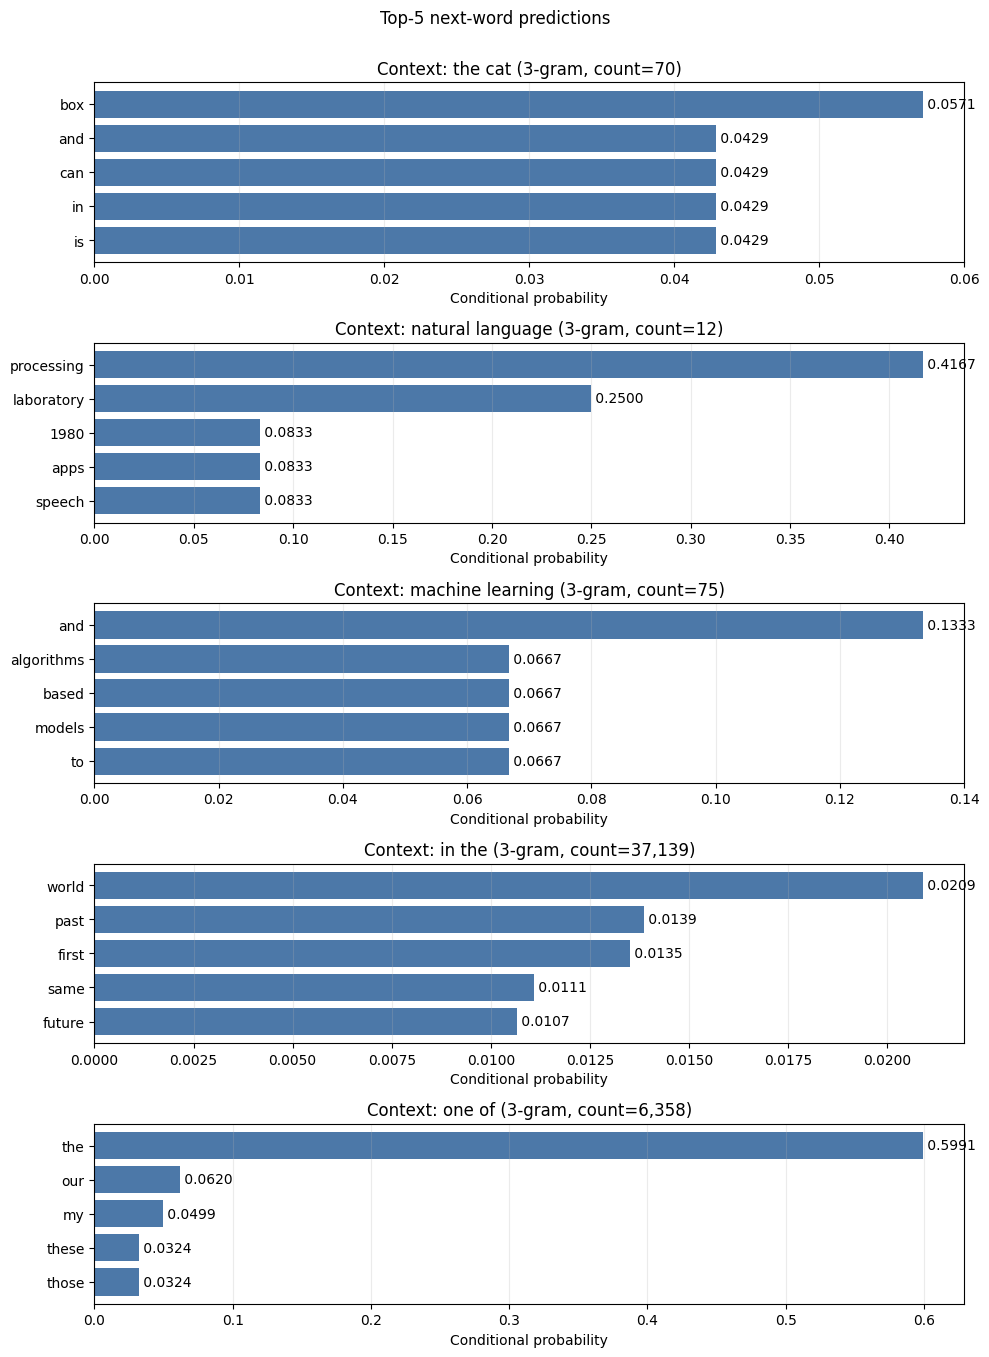

In [32]:
fig, axes = plt.subplots(
    len(prediction_rows),
    1,
    figsize=(10, 2.7 * len(prediction_rows)),
)

if len(prediction_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, prediction_rows):
    predictions = row["Top-5 predictions"]
    words = [word for word, _ in predictions][::-1]
    probabilities = [probability for _, probability in predictions][::-1]

    bars = ax.barh(words, probabilities, color="#4c78a8")
    ax.set_title(
        f"Context: {row['Context']} ({row['Used model']}, "
        f"count={row['Context count in train']:,})"
    )
    ax.set_xlabel("Conditional probability")
    ax.grid(axis="x", alpha=0.25)

    for bar, probability in zip(bars, probabilities):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {probability:.4f}",
            va="center",
        )

fig.suptitle("Top-5 next-word predictions", y=1.002)
fig.tight_layout()
plt.show()


### Nhận xét — Next-word prediction

- Cả năm context đều đã xuất hiện dưới dạng trigram context trong training,
  nên hệ thống không cần back off xuống bigram hoặc unigram.
- Hai context có count lớn nhất cho kết quả ổn định: `in the → world`
  (**37.139** lần làm context trong train) và `one of → the` (**6.358** lần).
  Trong đó `one of → the` có xác suất **0,5991**, cho thấy một collocation
  mạnh; `in the → world` chỉ có xác suất **0,0209** vì `in the` có rất nhiều
  continuation hợp lệ dù `world` đứng đầu.
- Với `the cat`, model dự đoán `box` (**0,0571**) trong khi actual được ghi là
  `family`. Prediction không xuất hiện trong actuals của test, cho thấy
  context này có phân phối continuation rộng và bằng chứng test rất ít.
- Với `natural language`, model dự đoán `processing` (**0,4167**). Test chứa
  cả `analysis` và `processing`, mỗi từ xuất hiện một lần; vì vậy việc chọn
  `analysis` làm “most common actual” chỉ là cách phá hòa, không phải một lỗi
  dự đoán rõ ràng.
- Tương tự, `machine learning → and` không khớp phần tử đầu tiên được chọn làm
  actual mode, nhưng `and` vẫn xuất hiện trong actuals và các continuation
  quan sát được đều rất hiếm. Trường hợp này phản ánh sparsity và tính đa
  nghĩa của continuation hơn là một đáp án duy nhất tuyệt đối.
- Theo tiêu chí nghiêm ngặt “khớp phần tử most-common được chọn”, model đúng
  **2/5 context**; theo tiêu chí prediction có xuất hiện trong actuals, model
  đạt **4/5 context**. Khi có tie, nên báo cáo cả danh sách mode thay vì chỉ
  một từ.


# 21. Application — Sentence ranking

Xếp hạng candidate bằng tổng log probability. Cột average log probability
được dùng để giảm thiên lệch do candidate dài có nhiều thừa số xác suất hơn.


In [33]:
def score_continuation(
    model,
    context_tokens,
    continuation_tokens,
    order=3,
    smoothing="laplace",
):
    context_tokens = list(context_tokens)
    continuation_tokens = list(continuation_tokens)

    if not continuation_tokens:
        return {
            "Probability": 1.0,
            "Log Probability": 0.0,
            "Average Log Probability": 0.0,
        }

    full_sequence = context_tokens + continuation_tokens
    log_probability = 0.0

    for index in range(len(context_tokens), len(full_sequence)):
        context_start = max(0, index - order + 1)
        word_probability = model.probability(
            full_sequence[context_start:index],
            full_sequence[index],
            order=order,
            smoothing=smoothing,
        )

        if word_probability == 0:
            return {
                "Probability": 0.0,
                "Log Probability": -math.inf,
                "Average Log Probability": -math.inf,
            }

        log_probability += math.log(word_probability)

    return {
        "Probability": math.exp(log_probability),
        "Log Probability": log_probability,
        "Average Log Probability": log_probability / len(continuation_tokens),
    }


In [34]:
ranking_context = "machine learning"
candidate_texts = {
    "A": "is useful for NLP",
    "B": "banana computer quickly",
    "C": "studies language models",
}

ranking_rows = []

for label, candidate_text in candidate_texts.items():
    scores = score_continuation(
        language_model,
        tokenize(ranking_context),
        tokenize(candidate_text),
    )
    ranking_rows.append({
        "Candidate": label,
        "Text": candidate_text,
        **scores,
    })

ranking_df = (
    pd.DataFrame(ranking_rows)
    .sort_values("Average Log Probability", ascending=False)
    .reset_index(drop=True)
)
ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))
display(ranking_df)


,Rank,Candidate,Text,Probability,Log Probability,Average Log Probability
0,1,A,is useful for NLP,2.049588e-20,-45.334063,-11.333516
1,2,B,banana computer quickly,1.883464e-16,-36.208249,-12.069416
2,3,C,studies language models,1.883453e-16,-36.208255,-12.069418


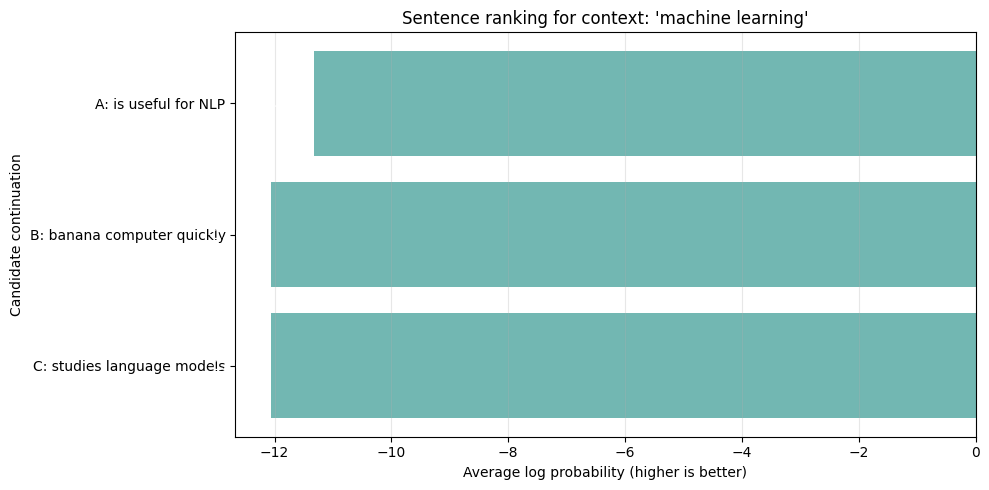

In [35]:
ranking_plot_df = ranking_df.sort_values(
    "Average Log Probability",
    ascending=True,
)

labels = [
    f"{candidate}: {text}"
    for candidate, text in zip(
        ranking_plot_df["Candidate"],
        ranking_plot_df["Text"],
    )
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    labels,
    ranking_plot_df["Average Log Probability"],
    color="#72b7b2",
)
ax.set_xlabel("Average log probability (higher is better)")
ax.set_ylabel("Candidate continuation")
ax.set_title(f"Sentence ranking for context: '{ranking_context}'")
ax.grid(axis="x", alpha=0.3)

for bar, value in zip(bars, ranking_plot_df["Average Log Probability"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        ha="right",
        color="white",
    )

fig.tight_layout()
plt.show()


### Nhận xét — Sentence ranking

- Candidate A (`is useful for NLP`) được xếp hạng 1 theo **Average Log
  Probability = -11,3335**, cao hơn B và C (xấp xỉ **-12,0694**). Theo thước
  đo đã chọn, A là continuation phù hợp nhất với context `machine learning`.
- Raw probability của A (**2,05×10⁻²⁰**) lại nhỏ hơn B/C
  (**1,88×10⁻¹⁶**) vì A có 4 token còn B/C có 3 token. Mỗi token bổ sung làm
  tích xác suất nhỏ đi; vì vậy raw sequence probability không công bằng khi
  so sánh các candidate khác độ dài.
- Average log probability chuẩn hóa theo số token và khắc phục phần lớn thiên
  lệch độ dài, nên được dùng để xếp hạng trong bảng.
- B (`banana computer quickly`) và C (`studies language models`) có score gần
  như bằng nhau. Nhiều n-gram trong hai candidate hiếm hoặc unseen nên
  Laplace đưa chúng về mức xác suất nền gần giống nhau. Đây là giới hạn của
  trigram + add-one: model chưa phân biệt tốt mức độ hợp lý về ngữ nghĩa.


# 22. Error analysis

Chọn hai dự đoán đúng và hai dự đoán sai từ bảng next-word prediction. Nguyên
nhân gợi ý gồm insufficient training data, unseen n-gram, vocabulary
limitation, sparsity, context quá ngắn, domain mismatch, preprocessing và
smoothing.


In [36]:
correct_cases = prediction_results[
    prediction_results["Matches most common actual"]
].head(2)

incorrect_cases = prediction_results[
    ~prediction_results["Matches most common actual"]
].head(2)

error_analysis_df = pd.concat(
    [correct_cases, incorrect_cases],
    ignore_index=True,
)[[
    "Context",
    "Prediction",
    "Most common actual",
    "Prediction probability",
    "Used model",
    "Context count in train",
    "Matches most common actual",
]]

error_analysis_df = error_analysis_df.rename(columns={
    "Most common actual": "Expected",
    "Prediction probability": "Probability",
})

display(error_analysis_df)

if len(correct_cases) < 2 or len(incorrect_cases) < 2:
    print(
        "Chưa đủ 2 trường hợp đúng và 2 trường hợp sai. "
        "Hãy bổ sung context vào danh sách contexts rồi chạy lại phần Application."
    )


,Context,Prediction,Expected,Probability,Used model,Context count in train,Matches most common actual
0,in the,world,world,0.020894,3-gram,37139,True
1,one of,the,the,0.599088,3-gram,6358,True
2,the cat,box,family,0.057143,3-gram,70,False
3,natural language,processing,analysis,0.416667,3-gram,12,False


### Nhận xét — Error analysis

**Hai prediction đúng**

1. `in the → world`: context xuất hiện **37.139** lần trong training. Dữ liệu
   lớn giúp ước lượng ổn định; `world` cũng là actual phổ biến nhất trong test.
   Xác suất chỉ **0,0209** vì context ngắn `in the` cho phép rất nhiều từ tiếp
   theo, không phải vì prediction yếu.
2. `one of → the`: context xuất hiện **6.358** lần và model gán xác suất
   **0,5991** cho `the`. Đây là một cụm từ có tính quy luật cao và có đủ dữ
   liệu train, nên prediction khớp actual mode.

**Hai trường hợp được bảng đánh dấu sai**

1. `the cat → box`, expected `family`: xác suất prediction **0,0571**, context
   count **70**. Nguyên nhân chính là continuation phân tán, số quan sát theo
   từng trigram nhỏ và có thể có domain mismatch giữa train/test; trong test
   chỉ thấy rất ít continuation cho context này.
2. `natural language → processing`, expected `analysis`: context count chỉ
   **12**, nên ước lượng còn sparse. Tuy nhiên test chứa `analysis` và
   `processing` cùng tần suất 1; `processing` vẫn là một actual continuation.
   Vì vậy đây là **tie/evaluation artifact** kết hợp với insufficient data,
   không nên coi là lỗi model hoàn toàn.

Nếu cần đúng hai trường hợp sai không mơ hồ, nên bổ sung context mà prediction
không xuất hiện trong actuals, thay vì dùng một context có nhiều mode đồng hạng.


In [37]:
# Export all required numeric results into one deliverable file.
experiment_2_export = experiment_2_df.copy()
experiment_2_export.insert(0, "Result type", "Experiment 2 perplexity")

experiment_3_export = experiment_3_df.copy()
experiment_3_export.insert(0, "Result type", "Experiment 3 perplexity")

prediction_export = prediction_results[[
    "Context",
    "Used model",
    "Context count in train",
    "Prediction",
    "Prediction probability",
    "Most common actual",
    "Prediction appears in actuals",
    "Matches most common actual",
]].copy()
prediction_export.insert(0, "Result type", "Next-word prediction")

combined_results = pd.concat(
    [experiment_2_export, experiment_3_export, prediction_export],
    ignore_index=True,
    sort=False,
)

results_path = LAB_DIR / "results.csv"
combined_results.to_csv(results_path, index=False)
print("Saved combined results to:", results_path)


Saved combined results to: D:\Study\Study_Class\Semester_7\NLP\Lab\lab02\results.csv
